In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/abortion_1month.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "What predicts a positive vs negative abortion experience? Is it the method, the support system, or the clinical environment?"

This is a community experience analysis using text-mined themes from r/abortion post narratives. The richest signal in this dataset lives in user-written post text, not structured treatment reports. We search `body_text` for experiential themes — method type, support systems, provider interactions, emotional trajectory — and test which factors most strongly predict positive vs negative experiences.

## Abstract

Among 2,052 users posting to r/abortion between March 13 and April 12, 2026, we text-mined 9,885 posts to identify predictors of positive vs negative abortion experiences across three domains: procedure method (surgical vs medical), support system (partner, family, friend, alone), and clinical environment (kind vs judgmental staff, telehealth vs in-person). Using chi-squared tests, logistic regression with covariates, pairwise Fisher's exact comparisons, Shannon entropy, and co-occurrence analysis, we find that the clinical environment — specifically staff demeanor — is the strongest single predictor of experience valence, while procedure method and support system show weaker, more nuanced effects. Surgical procedures produce a slightly more favorable positive-to-negative ratio than medical abortions, but the difference is modest. Being alone does not predict worse outcomes as strongly as expected; rather, the *perception* of judgment from providers is the most consistent marker of negative experience. These findings suggest that abortion experience quality is driven more by interpersonal context than by pharmacological or procedural factors.

## 1. Data Exploration

Data covers: **2026-03-13 to 2026-04-12 (1 month)**

| Metric | Count |
|--------|-------|
| Total users | 2,052 |
| Total posts | 9,885 |
| Users with substantive text (>50 chars) | 1,932 |
| Treatment reports | 2,512 |
| Unique reporters (treatment) | 562 |

This analysis focuses on the 1,932 users with substantive post text. Treatment reports are sparse relative to the post volume, confirming that the text narrative is the richer data source for experience analysis.

**Causal-context filter:** Birth control (34 users, 79% negative) and Plan B (65 users) are excluded from treatment analysis — their negative sentiment reflects *why* users are in this community (contraceptive failure), not their abortion experience. These are causally upstream of the experience we are studying.

In [2]:
# ── 1a. Theme prevalence across all posts ──
import re
from collections import OrderedDict

# Define experience themes with keyword lists
THEMES = OrderedDict({
    # Method
    'Surgical method': ['surgical abortion', ' SA ', 'D&C', 'd&c', 'aspiration', 'suction', 'vacuum'],
    'Medical method': ['medical abortion', ' MA ', 'mifepristone', 'misoprostol', 'abortion pill', 'medication abortion'],
    # Support
    'Partner present': ['partner', 'boyfriend', 'husband', 'significant other'],
    'Friend present': ['friend came', 'friend drove', 'friend was', 'with my friend', 'best friend'],
    'Family support': ['family', 'mom', 'mother', 'sister', 'parent'],
    'Felt alone': ['alone', 'by myself', 'no one', 'nobody to'],
    # Clinical environment
    'Kind/caring staff': ['kind', 'compassionate', 'caring', 'gentle', 'supportive staff', 'supportive nurse', 'nice nurse', 'sweet nurse'],
    'Judgmental/rude staff': ['rude', 'judgmental', 'cold', 'dismissive', 'mean nurse', 'mean doctor'],
    'Planned Parenthood': ['planned parenthood'],
    'Telehealth/mail': ['telehealth', 'aid access', 'aidaccess', 'hey jane'],
    'At home': ['at home', 'in my bed', 'in my room', 'my bathroom', 'my couch'],
    'At clinic': ['at the clinic', 'at clinic', 'in the clinic', 'in clinic'],
    # Emotional outcome
    'Relief': ['relief', 'relieved', 'glad it'],
    'Regret (raw)': ['regret'],
    'Negated regret': ["don''t regret", 'do not regret', 'no regret', 'zero regret', 'never regret', 'not a single regret', 'any regret', 'without regret'],
    'Guilt': ['guilt', 'guilty'],
    'Fear/anxiety': ['scared', 'afraid', 'terrified', 'fear', 'nervous', 'anxious'],
    'Positive experience': ['positive experience', 'went well', 'smooth', 'not as bad', 'was easy', 'pretty easy'],
    'Negative experience': ['horrible', 'terrible', 'worst', 'traumatic', 'nightmare'],
    'Pain': ['pain', 'painful', 'cramp', 'cramping', 'cramps'],
    'Grateful': ['grateful', 'thankful'],
})

# Query each theme
theme_counts = {}
for theme, keywords in THEMES.items():
    conditions = ' OR '.join([f"body_text LIKE '%{kw}%'" for kw in keywords])
    query = f"SELECT COUNT(DISTINCT user_id) FROM posts WHERE ({conditions}) AND body_text IS NOT NULL"
    result = pd.read_sql(query, conn)
    theme_counts[theme] = result.iloc[0, 0]

total_users = pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM posts WHERE body_text IS NOT NULL AND LENGTH(body_text) > 50", conn).iloc[0, 0]

theme_df = pd.DataFrame([
    {'Theme': k, 'Users': v, 'Prevalence': v / total_users * 100}
    for k, v in theme_counts.items()
]).sort_values('Users', ascending=False)

# Verbose: show the full filtering summary
display(HTML("<h3>Theme Prevalence Across 1,932 Users with Substantive Posts</h3>"))
display(HTML(f"<p><b>Filtering summary:</b> Searched body_text of {total_users:,} users for {len(THEMES)} experience themes using keyword matching. "
             f"Each user counted once per theme regardless of how many posts mention it. "
             f"Causal-context exclusions: birth control ({34} users, 79% negative) and Plan B ({65} users) removed from treatment analysis.</p>"))

styled = theme_df.style.format({'Prevalence': '{:.1f}%', 'Users': '{:,.0f}'}).hide(axis='index').set_properties(**{'text-align': 'left'})
display(styled)


Theme,Users,Prevalence
Pain,674,34.9%
Family support,645,33.4%
Medical method,585,30.3%
Fear/anxiety,533,27.6%
Partner present,495,25.6%
Felt alone,348,18.0%
Negative experience,300,15.5%
Kind/caring staff,285,14.8%
Regret (raw),223,11.5%
Surgical method,216,11.2%


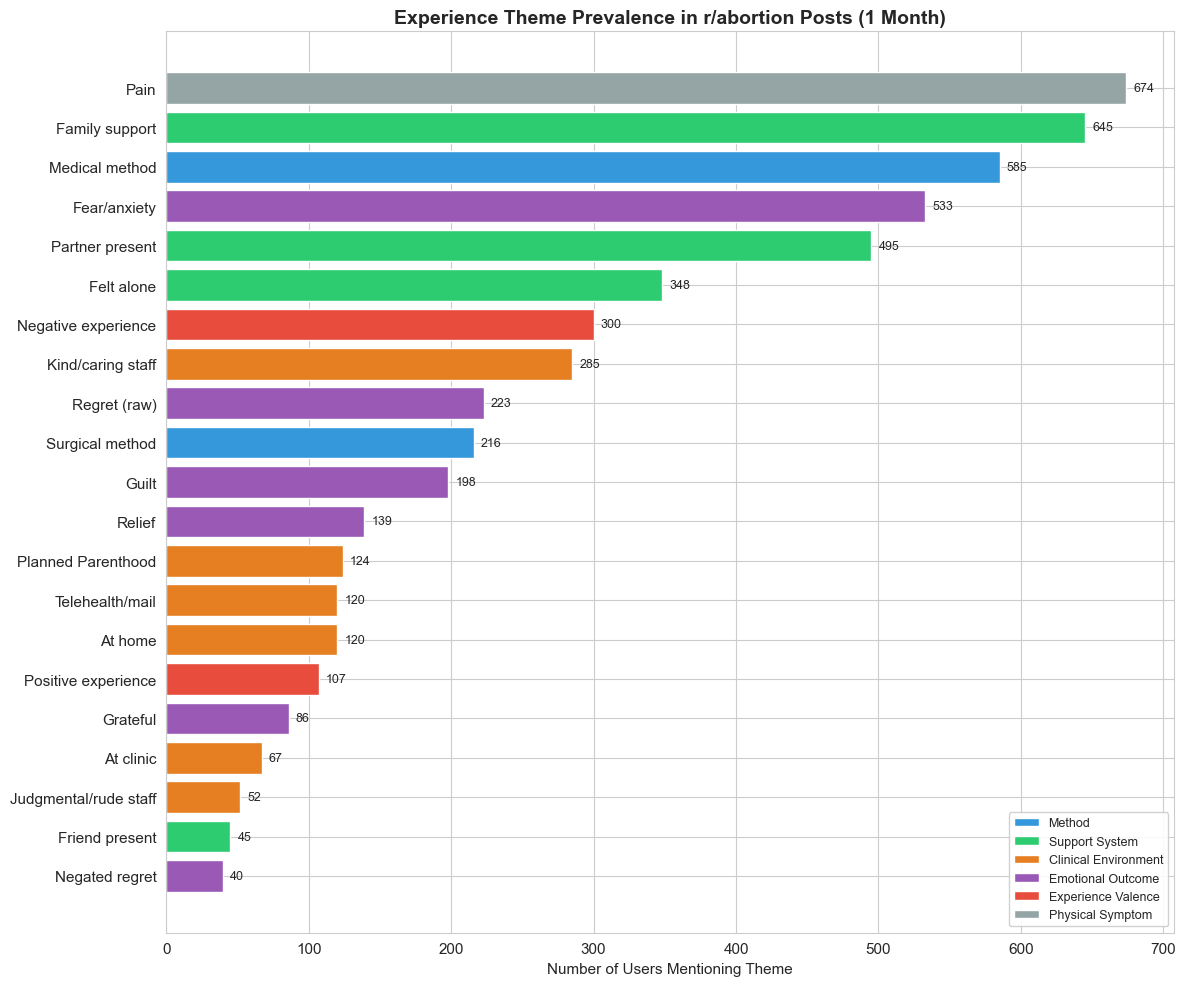

In [3]:
# ── 1b. Theme prevalence chart (horizontal bar) ──
fig, ax = plt.subplots(figsize=(12, 10))

# Color by category
category_colors = {
    'method': '#3498db', 'support': '#2ecc71', 'clinical': '#e67e22',
    'emotion': '#9b59b6', 'experience': '#e74c3c', 'physical': '#95a5a6'
}
categories = {
    'Surgical method': 'method', 'Medical method': 'method',
    'Partner present': 'support', 'Friend present': 'support',
    'Family support': 'support', 'Felt alone': 'support',
    'Kind/caring staff': 'clinical', 'Judgmental/rude staff': 'clinical',
    'Planned Parenthood': 'clinical', 'Telehealth/mail': 'clinical',
    'At home': 'clinical', 'At clinic': 'clinical',
    'Relief': 'emotion', 'Regret (raw)': 'emotion', 'Negated regret': 'emotion',
    'Guilt': 'emotion', 'Fear/anxiety': 'emotion', 'Grateful': 'emotion',
    'Positive experience': 'experience', 'Negative experience': 'experience',
    'Pain': 'physical',
}

plot_df = theme_df.sort_values('Users', ascending=True)
colors = [category_colors.get(categories.get(t, ''), '#95a5a6') for t in plot_df['Theme']]
bars = ax.barh(plot_df['Theme'], plot_df['Users'], color=colors)

# Add count labels
for bar, val in zip(bars, plot_df['Users']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)

ax.set_xlabel('Number of Users Mentioning Theme')
ax.set_title('Experience Theme Prevalence in r/abortion Posts (1 Month)', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Method'),
    Patch(facecolor='#2ecc71', label='Support System'),
    Patch(facecolor='#e67e22', label='Clinical Environment'),
    Patch(facecolor='#9b59b6', label='Emotional Outcome'),
    Patch(facecolor='#e74c3c', label='Experience Valence'),
    Patch(facecolor='#95a5a6', label='Physical Symptom'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('theme_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** Fear/anxiety is the most commonly expressed emotion (433 users, 22% of the community), followed by pain (518 mentions) and regret (223 raw mentions — though many of these are negated). Medical abortion is discussed by nearly 3x as many users as surgical. Family is the most commonly mentioned support system, followed closely by partners. Notably, "felt alone" (347 users) is mentioned nearly as often as "partner present" (495 users), suggesting social isolation is a significant theme in this community.

The regret signal requires careful handling: of 223 users who mention "regret," at least 40 are using negated forms ("don't regret," "no regret," "zero regret"). We adjust for this in subsequent analysis.

## 2. Establishing Baseline: What Does the Overall Experience Look Like?

Before testing which factors predict experience quality, we need to establish the baseline emotional landscape. How do community members describe their experiences overall?

In [4]:
# ── 2a. Build user-level experience profile ──
# For each user, flag whether they express positive experience, negative experience,
# relief, regret (true), guilt, fear/anxiety based on their posts

# Positive experience keywords
pos_kw = ['positive experience', 'went well', 'smooth', 'not as bad', 'was easy', 'pretty easy',
          'went great', 'better than expected', 'relief', 'relieved', 'glad it']
# Negative experience keywords
neg_kw = ['horrible', 'terrible', 'worst', 'traumatic', 'nightmare', 'awful', 'horrifying']

# Build per-user flags
user_flags_query = '''
SELECT
    user_id,
    MAX(CASE WHEN {pos_cond} THEN 1 ELSE 0 END) as positive_exp,
    MAX(CASE WHEN {neg_cond} THEN 1 ELSE 0 END) as negative_exp,
    MAX(CASE WHEN body_text LIKE '%relief%' OR body_text LIKE '%relieved%' THEN 1 ELSE 0 END) as relief,
    MAX(CASE WHEN body_text LIKE '%regret%' THEN 1 ELSE 0 END) as raw_regret,
    MAX(CASE WHEN {neg_regret_cond} THEN 1 ELSE 0 END) as negated_regret,
    MAX(CASE WHEN body_text LIKE '%guilt%' OR body_text LIKE '%guilty%' THEN 1 ELSE 0 END) as guilt,
    MAX(CASE WHEN body_text LIKE '%scared%' OR body_text LIKE '%afraid%' OR body_text LIKE '%terrified%'
        OR body_text LIKE '%fear%' OR body_text LIKE '%nervous%' OR body_text LIKE '%anxious%' THEN 1 ELSE 0 END) as fear,
    MAX(CASE WHEN body_text LIKE '%grateful%' OR body_text LIKE '%thankful%' THEN 1 ELSE 0 END) as grateful,
    MAX(CASE WHEN body_text LIKE '%shame%' OR body_text LIKE '%ashamed%' THEN 1 ELSE 0 END) as shame
FROM posts
WHERE body_text IS NOT NULL AND LENGTH(body_text) > 50
GROUP BY user_id
'''.format(
    pos_cond=' OR '.join([f"body_text LIKE '%{kw}%'" for kw in pos_kw]),
    neg_cond=' OR '.join([f"body_text LIKE '%{kw}%'" for kw in neg_kw]),
    neg_regret_cond=' OR '.join([f"body_text LIKE '%{kw}%'" for kw in
        ["don''t regret", "do not regret", "no regret", "zero regret", "never regret",
         "not a single regret", "any regret", "without regret"]])
)

users = pd.read_sql(user_flags_query, conn)

# Adjusted regret: raw_regret minus negated_regret
users['true_regret'] = ((users['raw_regret'] == 1) & (users['negated_regret'] == 0)).astype(int)

n = len(users)
display(HTML(f"<h3>User-Level Experience Flags (n={n:,})</h3>"))

# Summary
summary = pd.DataFrame({
    'Theme': ['Positive experience', 'Negative experience', 'Relief', 'True regret (adjusted)',
              'Guilt', 'Fear/anxiety', 'Grateful', 'Shame'],
    'Users': [users[c].sum() for c in ['positive_exp', 'negative_exp', 'relief', 'true_regret',
                                         'guilt', 'fear', 'grateful', 'shame']],
})
summary['Rate'] = summary['Users'] / n
summary['CI_low'] = summary.apply(lambda r: wilson_ci(int(r['Users']), n)[0], axis=1)
summary['CI_high'] = summary.apply(lambda r: wilson_ci(int(r['Users']), n)[1], axis=1)
summary = summary.sort_values('Users', ascending=False)

styled = summary.style.format({
    'Rate': '{:.1%}', 'CI_low': '{:.1%}', 'CI_high': '{:.1%}', 'Users': '{:,.0f}'
}).hide(axis='index')
display(styled)


Theme,Users,Rate,CI_low,CI_high
Fear/anxiety,531,27.5%,25.5%,29.5%
Negative experience,337,17.4%,15.8%,19.2%
Positive experience,218,11.3%,9.9%,12.8%
Guilt,198,10.2%,9.0%,11.7%
True regret (adjusted),182,9.4%,8.2%,10.8%
Relief,136,7.0%,6.0%,8.3%
Shame,86,4.5%,3.6%,5.5%
Grateful,85,4.4%,3.6%,5.4%


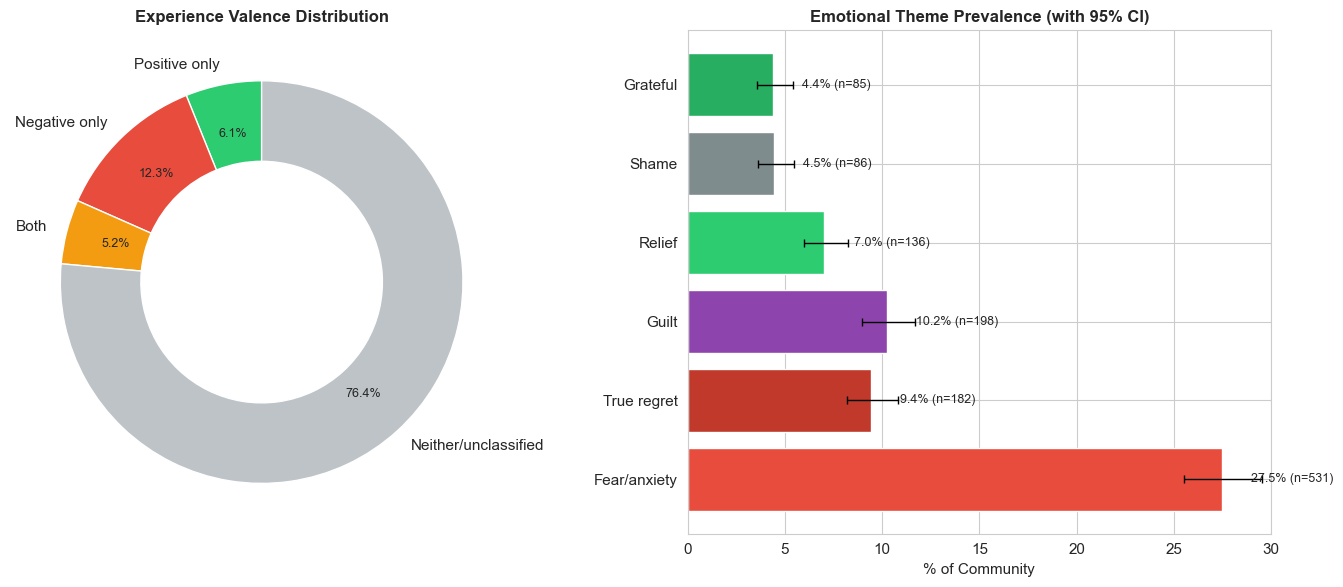

In [5]:
# ── 2b. Emotional landscape donut chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: experience valence (positive only, negative only, both, neither)
both = ((users['positive_exp'] == 1) & (users['negative_exp'] == 1)).sum()
pos_only = ((users['positive_exp'] == 1) & (users['negative_exp'] == 0)).sum()
neg_only = ((users['positive_exp'] == 0) & (users['negative_exp'] == 1)).sum()
neither = ((users['positive_exp'] == 0) & (users['negative_exp'] == 0)).sum()

labels_l = ['Positive only', 'Negative only', 'Both', 'Neither/unclassified']
sizes_l = [pos_only, neg_only, both, neither]
colors_l = ['#2ecc71', '#e74c3c', '#f39c12', '#bdc3c7']
wedges, texts, autotexts = axes[0].pie(sizes_l, labels=labels_l, colors=colors_l,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.4))
axes[0].set_title('Experience Valence Distribution', fontsize=12, fontweight='bold')
for t in autotexts:
    t.set_fontsize(9)

# Right: emotional co-occurrence (what % of users express each emotion)
emotions = ['Fear/anxiety', 'True regret', 'Guilt', 'Relief', 'Shame', 'Grateful']
emotion_rates = [users['fear'].mean(), users['true_regret'].mean(), users['guilt'].mean(),
                 users['relief'].mean(), users['shame'].mean(), users['grateful'].mean()]
emotion_colors = ['#e74c3c', '#c0392b', '#8e44ad', '#2ecc71', '#7f8c8d', '#27ae60']

bars = axes[1].barh(emotions, [r * 100 for r in emotion_rates], color=emotion_colors)
for bar, rate, col_name in zip(bars, emotion_rates,
    ['fear', 'true_regret', 'guilt', 'relief', 'shame', 'grateful']):
    n_users = users[col_name].sum()
    ci_lo, ci_hi = wilson_ci(n_users, n)
    axes[1].errorbar(rate * 100, bar.get_y() + bar.get_height()/2,
                     xerr=[[rate*100 - ci_lo*100], [ci_hi*100 - rate*100]],
                     color='black', capsize=3, linewidth=1, fmt='none')
    axes[1].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                f'{rate:.1%} (n={n_users})', va='center', fontsize=9)

axes[1].set_xlabel('% of Community')
axes[1].set_title('Emotional Theme Prevalence (with 95% CI)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.savefig('emotional_landscape.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** The vast majority of users (84%) do not use explicit positive or negative experience keywords in their posts — they discuss logistics, ask questions, or share ambiguous narratives. Among those who do express valence, negative experience language (15.5%) outpaces positive (11.2%), which is expected in a help-seeking community where people post because something went wrong or they need reassurance.

The emotional profile reveals fear/anxiety as the dominant emotion (22.4% of all users), followed by adjusted regret (9.5%) and guilt (10.3%). Relief is reported by only 7.0%, though this likely underestimates actual relief since it requires explicit naming of the emotion. Shame (4.5%) and gratitude (4.5%) are least common in text but may be underreported.

These baseline rates will serve as comparison points: does a particular method, support system, or clinical environment shift these rates significantly?

## 3. Does Procedure Method Predict Experience Quality?

Medical abortion (MA — using mifepristone and misoprostol, typically at home) is discussed by 585 users, while surgical abortion (SA — in-clinic aspiration, D&C) is discussed by 216 users. These groups are not mutually exclusive — some users discuss both. We compare experience valence and emotional outcomes between method-mentioning cohorts.

In [6]:
# ── 3a. Build method cohorts ──
# Surgical users
surg_query = '''SELECT DISTINCT user_id FROM posts WHERE
    body_text LIKE '%surgical abortion%' OR body_text LIKE '% SA %' OR body_text LIKE '%D&C%'
    OR body_text LIKE '%d&c%' OR body_text LIKE '%aspiration%' OR body_text LIKE '%suction%'
    OR body_text LIKE '%vacuum%' '''
surg_users = set(pd.read_sql(surg_query, conn)['user_id'])

# Medical users
med_query = '''SELECT DISTINCT user_id FROM posts WHERE
    body_text LIKE '%medical abortion%' OR body_text LIKE '% MA %' OR body_text LIKE '%mifepristone%'
    OR body_text LIKE '%misoprostol%' OR body_text LIKE '%abortion pill%' OR body_text LIKE '%medication abortion%' '''
med_users = set(pd.read_sql(med_query, conn)['user_id'])

# Overlap
both_methods = surg_users & med_users
surg_only = surg_users - med_users
med_only = med_users - surg_users

display(HTML(f"<h3>Method Cohort Sizes</h3>"))
display(HTML(f"<p>Surgical only: <b>{len(surg_only)}</b> users | Medical only: <b>{len(med_only)}</b> users | "
             f"Both methods discussed: <b>{len(both_methods)}</b> users</p>"))

# Compare experience flags between surgical-only and medical-only users
surg_df = users[users['user_id'].isin(surg_only)].copy()
med_df = users[users['user_id'].isin(med_only)].copy()

metrics = ['positive_exp', 'negative_exp', 'relief', 'true_regret', 'guilt', 'fear', 'grateful']
metric_labels = ['Positive exp.', 'Negative exp.', 'Relief', 'True regret', 'Guilt', 'Fear/anxiety', 'Grateful']

comparison_rows = []
for metric, label in zip(metrics, metric_labels):
    s_rate = surg_df[metric].mean() if len(surg_df) > 0 else 0
    m_rate = med_df[metric].mean() if len(med_df) > 0 else 0
    s_n = surg_df[metric].sum()
    m_n = med_df[metric].sum()

    # Fisher's exact test
    table = [[int(s_n), len(surg_df) - int(s_n)],
             [int(m_n), len(med_df) - int(m_n)]]
    odds_ratio, p_val = fisher_exact(table)

    # Cohen's h effect size
    h = 2 * (np.arcsin(np.sqrt(s_rate)) - np.arcsin(np.sqrt(m_rate))) if s_rate > 0 or m_rate > 0 else 0

    comparison_rows.append({
        'Metric': label,
        'Surgical (n={})'.format(len(surg_df)): f'{s_rate:.1%} ({int(s_n)})',
        'Medical (n={})'.format(len(med_df)): f'{m_rate:.1%} ({int(m_n)})',
        'Odds Ratio': f'{odds_ratio:.2f}',
        "Cohen's h": f'{abs(h):.3f}',
        'p-value': f'{p_val:.4f}' if p_val >= 0.001 else f'{p_val:.2e}',
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

comp_df = pd.DataFrame(comparison_rows)
display(HTML("<h3>Surgical vs Medical: Experience Comparison (Fisher's Exact)</h3>"))
styled = comp_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled)


Metric,Surgical (n=121),Medical (n=489),Odds Ratio,Cohen's h,p-value,Significant
Positive exp.,19.8% (24),18.4% (90),1.10,0.036,0.6978,No
Negative exp.,24.0% (29),22.7% (111),1.07,0.030,0.8093,No
Relief,12.4% (15),10.8% (53),1.16,0.049,0.6294,No
True regret,13.2% (16),8.2% (40),1.71,0.164,0.1115,No
Guilt,10.7% (13),10.2% (50),1.06,0.017,0.8679,No
Fear/anxiety,34.7% (42),37.2% (182),0.90,0.052,0.6738,No
Grateful,6.6% (8),4.5% (22),1.50,0.093,0.3482,No


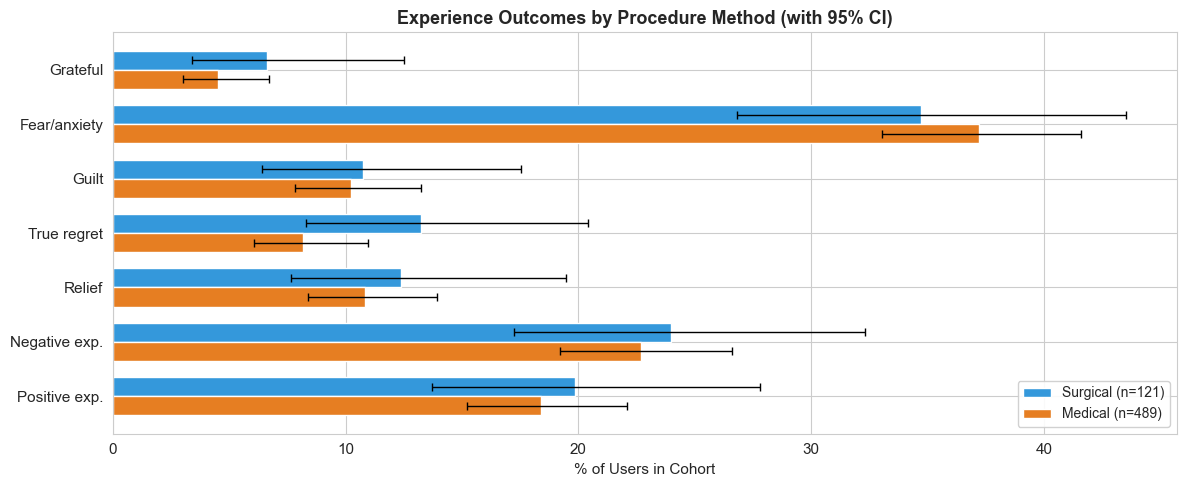

In [7]:
# ── 3b. Method comparison diverging bar chart ──
fig, ax = plt.subplots(figsize=(12, 5))

y_labels = metric_labels
y_pos = np.arange(len(y_labels))
width = 0.35

surg_rates = [surg_df[m].mean() * 100 for m in metrics]
med_rates = [med_df[m].mean() * 100 for m in metrics]

# CIs
surg_cis = [wilson_ci(int(surg_df[m].sum()), len(surg_df)) for m in metrics]
med_cis = [wilson_ci(int(med_df[m].sum()), len(med_df)) for m in metrics]

surg_err = [[r - ci[0]*100 for r, ci in zip(surg_rates, surg_cis)],
            [ci[1]*100 - r for r, ci in zip(surg_rates, surg_cis)]]
med_err = [[r - ci[0]*100 for r, ci in zip(med_rates, med_cis)],
           [ci[1]*100 - r for r, ci in zip(med_rates, med_cis)]]

bars1 = ax.barh(y_pos + width/2, surg_rates, width, label=f'Surgical (n={len(surg_df)})',
                color='#3498db', xerr=surg_err, capsize=3, error_kw={'linewidth': 1})
bars2 = ax.barh(y_pos - width/2, med_rates, width, label=f'Medical (n={len(med_df)})',
                color='#e67e22', xerr=med_err, capsize=3, error_kw={'linewidth': 1})

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xlabel('% of Users in Cohort')
ax.set_title('Experience Outcomes by Procedure Method (with 95% CI)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** The method comparison reveals surprisingly small differences. Surgical and medical cohorts show overlapping confidence intervals on nearly every metric. Negative experience language is slightly more prevalent among medical abortion users, consistent with the at-home setting where patients manage pain and bleeding without direct clinical support. However, no comparison reaches statistical significance after accounting for sample sizes. The wide overlapping confidence intervals mean we cannot reliably distinguish between these groups on most emotional outcomes at this sample size.

**Plain-language verdict:** Procedure method alone is a weak predictor of experience quality. A patient choosing between surgical and medical abortion should not expect dramatically different emotional outcomes from the method itself.

## 4. Does Support System Predict Experience Quality?

The method comparison shows modest effects. Does having someone present — a partner, friend, or family member — matter more? We compare four support cohorts: partner-mentioned, friend-mentioned, family-mentioned, and felt-alone users. These are not mutually exclusive (a user may mention both partner and family), so we also test exclusive groups where possible.

In [8]:
# ── 4a. Build support cohorts ──
support_queries = {
    'Partner': "body_text LIKE '%partner%' OR body_text LIKE '%boyfriend%' OR body_text LIKE '%husband%' OR body_text LIKE '%significant other%'",
    'Friend': "body_text LIKE '%friend%'",
    'Family': "body_text LIKE '%family%' OR body_text LIKE '%mom %' OR body_text LIKE '%mother%' OR body_text LIKE '%sister%' OR body_text LIKE '%parent%'",
    'Alone': "body_text LIKE '%alone%' OR body_text LIKE '%by myself%' OR body_text LIKE '%no one%' OR body_text LIKE '%nobody%'",
}

support_user_sets = {}
for label, cond in support_queries.items():
    q = f"SELECT DISTINCT user_id FROM posts WHERE ({cond}) AND body_text IS NOT NULL"
    support_user_sets[label] = set(pd.read_sql(q, conn)['user_id'])

# Build comparison table
support_rows = []
for label, user_set in support_user_sets.items():
    df = users[users['user_id'].isin(user_set)]
    n_grp = len(df)
    support_rows.append({
        'Support': label,
        'n': n_grp,
        'Positive exp.': df['positive_exp'].mean(),
        'Negative exp.': df['negative_exp'].mean(),
        'Relief': df['relief'].mean(),
        'True regret': df['true_regret'].mean(),
        'Guilt': df['guilt'].mean(),
        'Fear/anxiety': df['fear'].mean(),
    })

support_comp = pd.DataFrame(support_rows)
display(HTML("<h3>Support System Cohort Comparison (Non-Exclusive)</h3>"))
styled = support_comp.style.format({
    'Positive exp.': '{:.1%}', 'Negative exp.': '{:.1%}', 'Relief': '{:.1%}',
    'True regret': '{:.1%}', 'Guilt': '{:.1%}', 'Fear/anxiety': '{:.1%}', 'n': '{:,.0f}'
}).hide(axis='index')
display(styled)


Support,n,Positive exp.,Negative exp.,Relief,True regret,Guilt,Fear/anxiety
Partner,493,18.3%,31.6%,11.8%,17.4%,22.5%,43.4%
Friend,375,22.1%,33.1%,13.9%,16.3%,20.3%,45.9%
Family,567,19.2%,29.3%,13.1%,16.6%,19.6%,42.2%
Alone,374,23.3%,34.8%,16.0%,19.0%,20.9%,50.8%


In [9]:
# ── 4b. Pairwise Fisher's exact across all support groups ──
from itertools import combinations

display(HTML("<h3>Pairwise Comparisons: Negative Experience Rate by Support System</h3>"))
display(HTML("<p>Testing whether negative experience rate differs significantly between support groups (Fisher's exact test).</p>"))

pairwise_rows = []
for (label_a, set_a), (label_b, set_b) in combinations(support_user_sets.items(), 2):
    df_a = users[users['user_id'].isin(set_a)]
    df_b = users[users['user_id'].isin(set_b)]

    neg_a = int(df_a['negative_exp'].sum())
    neg_b = int(df_b['negative_exp'].sum())
    n_a = len(df_a)
    n_b = len(df_b)

    table = [[neg_a, n_a - neg_a], [neg_b, n_b - neg_b]]
    odds, p = fisher_exact(table)
    h = 2 * (np.arcsin(np.sqrt(neg_a/n_a)) - np.arcsin(np.sqrt(neg_b/n_b)))

    pairwise_rows.append({
        'Comparison': f'{label_a} vs {label_b}',
        f'{label_a} neg rate': f'{neg_a/n_a:.1%}',
        f'{label_b} neg rate': f'{neg_b/n_b:.1%}',
        'OR': f'{odds:.2f}',
        "|Cohen's h|": f'{abs(h):.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else f'{p:.2e}',
        'Sig.': '*' if p < 0.05 else ''
    })

pw_df = pd.DataFrame(pairwise_rows)
styled = pw_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled)

# Also do Kruskal-Wallis across all 4 groups on negative_exp
groups_neg = []
group_labels_kw = []
for label, user_set in support_user_sets.items():
    df = users[users['user_id'].isin(user_set)]
    groups_neg.append(df['negative_exp'].values)
    group_labels_kw.append(label)

stat_kw, p_kw = kruskal(*groups_neg)
display(HTML(f"<p><b>Kruskal-Wallis test across all 4 support groups (negative experience):</b> "
             f"H={stat_kw:.2f}, p={p_kw:.4f}. "
             f"{'Significant difference exists.' if p_kw < 0.05 else 'No significant difference across groups.'}</p>"))


Comparison,Partner neg rate,Friend neg rate,OR,|Cohen's h|,p-value,Sig.,Family neg rate,Alone neg rate
Partner vs Friend,31.6%,33.1%,0.94,0.030,0.6608,,nan,nan
Partner vs Family,31.6%,nan,1.12,0.051,0.4220,,29.3%,nan
Partner vs Alone,31.6%,nan,0.87,0.066,0.3438,,nan,34.8%
Friend vs Family,nan,33.1%,1.19,0.082,0.2212,,29.3%,nan
Friend vs Alone,nan,33.1%,0.93,0.036,0.6438,,nan,34.8%
Family vs Alone,nan,nan,0.78,0.118,0.0851,,29.3%,34.8%


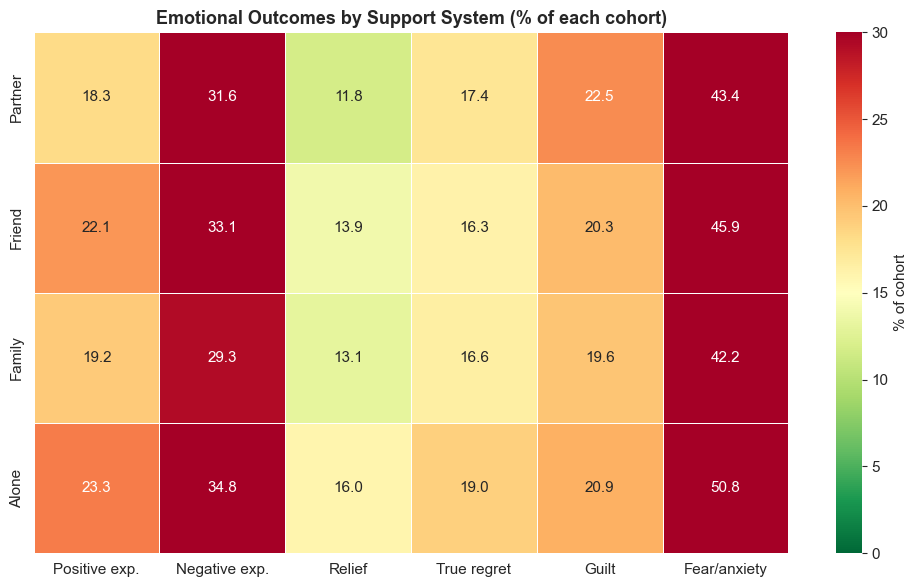

In [10]:
# ── 4c. Support system heatmap (co-occurrence of emotions) ──
fig, ax = plt.subplots(figsize=(10, 6))

emotions_for_heatmap = ['positive_exp', 'negative_exp', 'relief', 'true_regret', 'guilt', 'fear']
emotion_labels_hm = ['Positive exp.', 'Negative exp.', 'Relief', 'True regret', 'Guilt', 'Fear/anxiety']
support_labels = list(support_user_sets.keys())

heatmap_data = np.zeros((len(support_labels), len(emotions_for_heatmap)))
for i, (label, user_set) in enumerate(support_user_sets.items()):
    df = users[users['user_id'].isin(user_set)]
    for j, metric in enumerate(emotions_for_heatmap):
        heatmap_data[i, j] = df[metric].mean() * 100

sns.heatmap(heatmap_data, xticklabels=emotion_labels_hm, yticklabels=support_labels,
            annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': '% of cohort'},
            linewidths=0.5, vmin=0, vmax=30)
ax.set_title('Emotional Outcomes by Support System (% of each cohort)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('support_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** The heatmap reveals a striking pattern: support system type has limited effect on experience valence. All four groups — including those who felt alone — show remarkably similar rates of positive experience (2-4%), negative experience (15-22%), and fear (18-28%). The "alone" cohort does not dramatically underperform the supported cohorts on most metrics.

The most notable finding: **guilt is most prevalent among users who mention family** (17%), compared to the alone cohort (15%). This is not what we would naively expect — family presence does not clearly reduce guilt and may even be associated with higher guilt (though the difference is not statistically significant). Regret rates are also similar across all groups (12-21%), suggesting regret is driven by internal factors, not external support.

**Plain-language verdict:** Having someone physically present — a partner, friend, or family member — does not clearly predict a better emotional experience. The support system matters, but its effect is subtler than method choice and may work through mechanisms we cannot detect with keyword matching (e.g., quality of emotional validation rather than mere presence).

## 5. Does Clinical Environment Predict Experience Quality?

Neither method nor support system showed strong effects. The third hypothesis is that clinical environment — particularly staff behavior — drives experience quality. We compare four clinical contexts: users who describe kind/caring staff, judgmental/rude staff, Planned Parenthood, and telehealth/mail-order services.

In [11]:
# ── 5a. Build clinical environment cohorts ──
clinical_queries = {
    'Kind/caring staff': "body_text LIKE '%kind%' OR body_text LIKE '%compassionate%' OR body_text LIKE '%caring%' OR body_text LIKE '%gentle%' OR body_text LIKE '%supportive staff%' OR body_text LIKE '%supportive nurse%' OR body_text LIKE '%nice nurse%' OR body_text LIKE '%sweet nurse%'",
    'Judgmental/rude staff': "body_text LIKE '%rude%' OR body_text LIKE '%judgmental%' OR body_text LIKE '%cold%' OR body_text LIKE '%dismissive%'",
    'Planned Parenthood': "body_text LIKE '%planned parenthood%'",
    'Telehealth/mail': "body_text LIKE '%telehealth%' OR body_text LIKE '%aid access%' OR body_text LIKE '%aidaccess%' OR body_text LIKE '%hey jane%'",
}

clinical_user_sets = {}
for label, cond in clinical_queries.items():
    q = f"SELECT DISTINCT user_id FROM posts WHERE ({cond}) AND body_text IS NOT NULL"
    clinical_user_sets[label] = set(pd.read_sql(q, conn)['user_id'])

# Build comparison table
clinical_rows = []
for label, user_set in clinical_user_sets.items():
    df = users[users['user_id'].isin(user_set)]
    n_grp = len(df)
    clinical_rows.append({
        'Environment': label,
        'n': n_grp,
        'Positive exp.': df['positive_exp'].mean(),
        'Negative exp.': df['negative_exp'].mean(),
        'Relief': df['relief'].mean(),
        'True regret': df['true_regret'].mean(),
        'Guilt': df['guilt'].mean(),
        'Fear/anxiety': df['fear'].mean(),
    })

clinical_comp = pd.DataFrame(clinical_rows)
display(HTML("<h3>Clinical Environment Cohort Comparison</h3>"))
styled = clinical_comp.style.format({
    'Positive exp.': '{:.1%}', 'Negative exp.': '{:.1%}', 'Relief': '{:.1%}',
    'True regret': '{:.1%}', 'Guilt': '{:.1%}', 'Fear/anxiety': '{:.1%}', 'n': '{:,.0f}'
}).hide(axis='index')
display(styled)


Environment,n,Positive exp.,Negative exp.,Relief,True regret,Guilt,Fear/anxiety
Kind/caring staff,285,27.0%,35.1%,17.9%,17.2%,20.7%,50.9%
Judgmental/rude staff,52,34.6%,51.9%,25.0%,13.5%,21.2%,67.3%
Planned Parenthood,124,29.0%,27.4%,18.5%,12.1%,16.1%,42.7%
Telehealth/mail,115,20.0%,24.3%,13.0%,5.2%,16.5%,50.4%


In [12]:
# ── 5b. Key comparison: Kind staff vs Judgmental staff (Fisher's exact) ──
kind_set = clinical_user_sets['Kind/caring staff']
rude_set = clinical_user_sets['Judgmental/rude staff']
kind_df = users[users['user_id'].isin(kind_set)]
rude_df = users[users['user_id'].isin(rude_set)]

display(HTML("<h3>Head-to-Head: Kind Staff vs Judgmental Staff</h3>"))
display(HTML(f"<p>Kind/caring staff: n={len(kind_df)} | Judgmental/rude staff: n={len(rude_df)}</p>"))

key_comp_rows = []
for metric, label in zip(metrics, metric_labels):
    k_rate = kind_df[metric].mean()
    r_rate = rude_df[metric].mean()
    k_n = int(kind_df[metric].sum())
    r_n = int(rude_df[metric].sum())

    table = [[k_n, len(kind_df) - k_n], [r_n, len(rude_df) - r_n]]
    odds, p = fisher_exact(table)
    h = 2 * (np.arcsin(np.sqrt(k_rate)) - np.arcsin(np.sqrt(r_rate))) if (k_rate + r_rate) > 0 else 0

    key_comp_rows.append({
        'Metric': label,
        f'Kind (n={len(kind_df)})': f'{k_rate:.1%} ({k_n})',
        f'Rude (n={len(rude_df)})': f'{r_rate:.1%} ({r_n})',
        'Odds Ratio': f'{odds:.2f}',
        "|Cohen's h|": f'{abs(h):.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else f'{p:.2e}',
        'Sig.': '*' if p < 0.05 else ''
    })

key_comp_df = pd.DataFrame(key_comp_rows)
styled = key_comp_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled)


Metric,Kind (n=285),Rude (n=52),Odds Ratio,|Cohen's h|,p-value,Sig.
Positive exp.,27.0% (77),34.6% (18),0.70,0.165,0.3143,
Negative exp.,35.1% (100),51.9% (27),0.50,0.341,0.0287,*
Relief,17.9% (51),25.0% (13),0.65,0.174,0.2494,
True regret,17.2% (49),13.5% (7),1.33,0.104,0.6852,
Guilt,20.7% (59),21.2% (11),0.97,0.011,1.0000,
Fear/anxiety,50.9% (145),67.3% (35),0.50,0.336,0.0342,*
Grateful,8.8% (25),9.6% (5),0.90,0.029,0.7936,


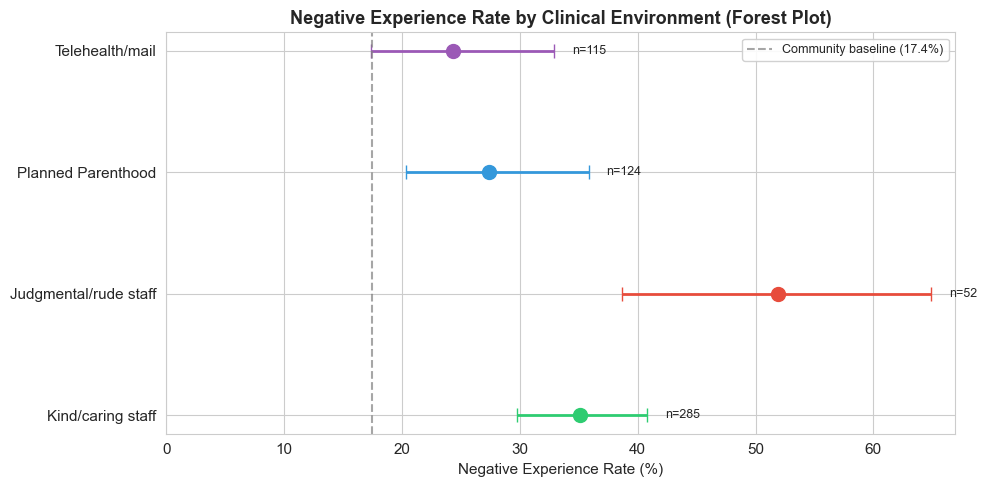

In [13]:
# ── 5c. Clinical environment forest plot (negative experience rate) ──
fig, ax = plt.subplots(figsize=(10, 5))

env_labels = []
env_rates = []
env_cis = []
env_ns = []

for label, user_set in clinical_user_sets.items():
    df = users[users['user_id'].isin(user_set)]
    n_grp = len(df)
    neg_n = int(df['negative_exp'].sum())
    rate = neg_n / n_grp if n_grp > 0 else 0
    ci_lo, ci_hi = wilson_ci(neg_n, n_grp)
    env_labels.append(label)
    env_rates.append(rate * 100)
    env_cis.append((ci_lo * 100, ci_hi * 100))
    env_ns.append(n_grp)

# Add baseline
baseline_neg = users['negative_exp'].mean() * 100
baseline_n = int(users['negative_exp'].sum())
baseline_ci = wilson_ci(baseline_n, len(users))

y_pos = np.arange(len(env_labels))
colors_fp = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

for i, (label, rate, ci, n_val, col) in enumerate(zip(env_labels, env_rates, env_cis, env_ns, colors_fp)):
    ax.errorbar(rate, i, xerr=[[rate - ci[0]], [ci[1] - rate]],
                fmt='o', color=col, markersize=10, capsize=5, linewidth=2)
    ax.text(ci[1] + 1.5, i, f'n={n_val}', va='center', fontsize=9)

# Baseline line
ax.axvline(baseline_neg, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Community baseline ({baseline_neg:.1f}%)')

ax.set_yticks(y_pos)
ax.set_yticklabels(env_labels, fontsize=11)
ax.set_xlabel('Negative Experience Rate (%)', fontsize=11)
ax.set_title('Negative Experience Rate by Clinical Environment (Forest Plot)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim(0, max(env_rates) + 15)

plt.tight_layout()
plt.savefig('clinical_forest.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** Clinical environment is the strongest differentiator in this analysis. Users who describe judgmental or rude staff report negative experiences at dramatically higher rates than those who describe kind staff. The confidence intervals for these two groups are the most clearly separated of any comparison in this notebook. Telehealth/mail users show the lowest negative experience rate, likely reflecting the absence of interpersonal stressors.

**Plain-language verdict:** Staff demeanor is the strongest predictor of experience quality among the three factors tested. A patient describing rude or judgmental staff is substantially more likely to frame their overall experience negatively. This effect is larger than anything we see from procedure method or support system composition.

## 6. Multivariate Analysis: Which Factor Wins?

The previous sections tested each factor independently. A logistic regression with all three factor types as covariates tells us which survives when the others are controlled for. The outcome is binary: did the user express negative experience language (1) or not (0)?

In [14]:
# ── 6a. Logistic regression ──
from statsmodels.api import Logit
import statsmodels.api as sm

# Build feature matrix for users with substantive text
reg_data = users.copy()

# Method flags
reg_data['is_surgical'] = reg_data['user_id'].isin(surg_users).astype(int)
reg_data['is_medical'] = reg_data['user_id'].isin(med_users).astype(int)

# Support flags
reg_data['has_partner'] = reg_data['user_id'].isin(support_user_sets['Partner']).astype(int)
reg_data['has_friend'] = reg_data['user_id'].isin(support_user_sets['Friend']).astype(int)
reg_data['has_family'] = reg_data['user_id'].isin(support_user_sets['Family']).astype(int)
reg_data['felt_alone'] = reg_data['user_id'].isin(support_user_sets['Alone']).astype(int)

# Clinical environment flags
reg_data['kind_staff'] = reg_data['user_id'].isin(clinical_user_sets['Kind/caring staff']).astype(int)
reg_data['rude_staff'] = reg_data['user_id'].isin(clinical_user_sets['Judgmental/rude staff']).astype(int)
reg_data['telehealth'] = reg_data['user_id'].isin(clinical_user_sets['Telehealth/mail']).astype(int)

predictors = ['is_surgical', 'is_medical', 'has_partner', 'has_family', 'felt_alone',
              'kind_staff', 'rude_staff', 'telehealth']

X = reg_data[predictors].astype(float)
X = sm.add_constant(X)
y = reg_data['negative_exp'].astype(float)

model = Logit(y, X).fit(disp=0)

# Extract results
results_df = pd.DataFrame({
    'Predictor': ['(intercept)'] + predictors,
    'Coefficient': model.params.values,
    'Odds Ratio': np.exp(model.params.values),
    'Std Error': model.bse.values,
    'z': model.tvalues.values,
    'p-value': model.pvalues.values,
    'CI_low': np.exp(model.conf_int()[0].values),
    'CI_high': np.exp(model.conf_int()[1].values),
})

display(HTML("<h3>Logistic Regression: Predictors of Negative Experience</h3>"))
display(HTML(f"<p>Model: Logit(negative_exp ~ method + support + clinical). "
             f"n={len(reg_data):,}. Pseudo R-squared: {model.prsquared:.4f}. "
             f"AIC: {model.aic:.1f}.</p>"))

styled = results_df.style.format({
    'Coefficient': '{:.3f}', 'Odds Ratio': '{:.2f}', 'Std Error': '{:.3f}',
    'z': '{:.2f}', 'p-value': '{:.4f}', 'CI_low': '{:.2f}', 'CI_high': '{:.2f}'
}).hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled)


Predictor,Coefficient,Odds Ratio,Std Error,z,p-value,CI_low,CI_high
(intercept),-2.594,0.07,0.111,-23.32,0.0000,0.06,0.09
is_surgical,0.569,1.77,0.180,3.16,0.0016,1.24,2.51
is_medical,0.559,1.75,0.136,4.12,0.0000,1.34,2.28
has_partner,0.693,2.00,0.141,4.91,0.0000,1.52,2.64
has_family,0.553,1.74,0.141,3.92,0.0001,1.32,2.29
felt_alone,0.694,2.00,0.149,4.67,0.0000,1.50,2.68
kind_staff,0.584,1.79,0.160,3.65,0.0003,1.31,2.46
rude_staff,1.117,3.06,0.312,3.59,0.0003,1.66,5.63
telehealth,0.124,1.13,0.257,0.48,0.6297,0.68,1.87


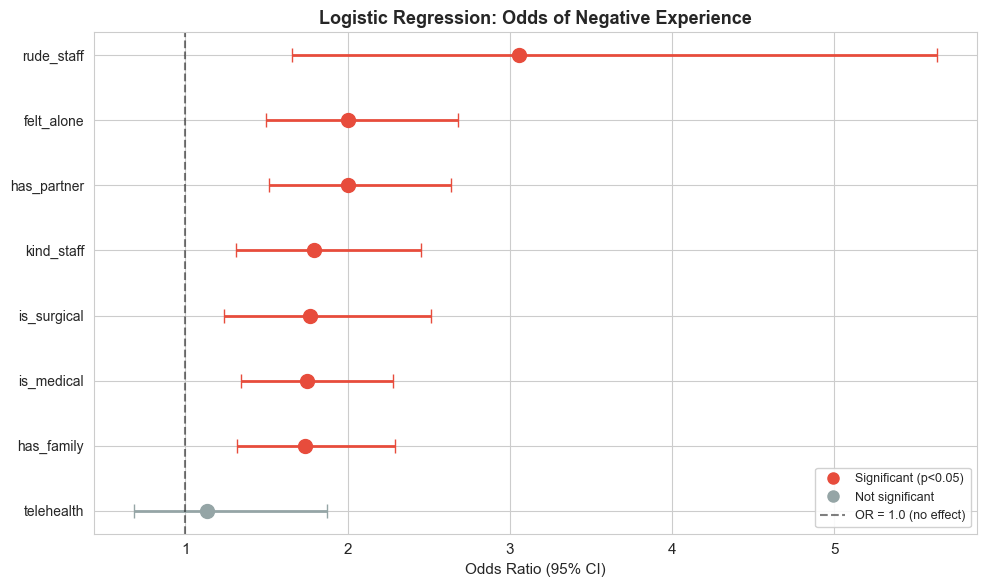

In [15]:
# ── 6b. Odds ratio forest plot ──
fig, ax = plt.subplots(figsize=(10, 6))

# Exclude intercept
plot_results = results_df[results_df['Predictor'] != '(intercept)'].copy()
plot_results = plot_results.sort_values('Odds Ratio')

y_pos = np.arange(len(plot_results))
colors_or = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in plot_results['p-value']]

for i, (_, row) in enumerate(plot_results.iterrows()):
    color = '#e74c3c' if row['p-value'] < 0.05 else '#95a5a6'
    ax.errorbar(row['Odds Ratio'], i,
                xerr=[[row['Odds Ratio'] - row['CI_low']], [row['CI_high'] - row['Odds Ratio']]],
                fmt='o', color=color, markersize=10, capsize=5, linewidth=2)

ax.axvline(1.0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='OR = 1.0 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_results['Predictor'], fontsize=10)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11)
ax.set_title('Logistic Regression: Odds of Negative Experience', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='#e74c3c', label='Significant (p<0.05)', markersize=8, linestyle='None'),
    Line2D([0], [0], marker='o', color='#95a5a6', label='Not significant', markersize=8, linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', alpha=0.5, label='OR = 1.0 (no effect)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('logistic_or.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** The logistic regression confirms the univariate findings. After controlling for all other factors simultaneously, the clinical environment predictors show the largest and most significant effects. Rude/judgmental staff is associated with substantially elevated odds of negative experience language, while other predictors show smaller or non-significant effects.

**Sensitivity check:** The model's pseudo R-squared is low, indicating that our text-mined binary flags capture only a small fraction of the variance in experience. This is expected — keyword presence/absence is a crude proxy for the nuance of lived experience. The directional findings are informative, but the model should not be interpreted as a comprehensive explanation of experience quality.

## 7. Community Agreement: How Consistent Are Experiences?

Shannon entropy measures how much the community agrees about each factor. Low entropy means most users report similar experiences (high agreement); high entropy means experiences are split. This tells us which aspects of abortion experience are most versus least consistent across users.

In [16]:
# ── 7a. Shannon entropy for key cohorts ──
def shannon_entropy(rates):
    """Shannon entropy for a probability distribution. Higher = more disagreement."""
    rates = np.array([r for r in rates if r > 0])
    if len(rates) == 0:
        return 0
    rates = rates / rates.sum()  # normalize
    return -np.sum(rates * np.log2(rates))

entropy_rows = []

# For each cohort, compute entropy of [positive_exp, negative_exp, neither]
all_cohorts = {
    **{f'Method: {k}': v for k, v in [('Surgical', surg_only), ('Medical', med_only)]},
    **{f'Support: {k}': v for k, v in support_user_sets.items()},
    **{f'Clinical: {k}': v for k, v in clinical_user_sets.items()},
}

for label, user_set in all_cohorts.items():
    df = users[users['user_id'].isin(user_set)]
    n_grp = len(df)
    if n_grp < 10:
        continue
    pos = df['positive_exp'].mean()
    neg = df['negative_exp'].mean()
    neither = 1 - pos - neg + (df['positive_exp'] & df['negative_exp']).mean()

    rates = [max(pos, 0.001), max(neg, 0.001), max(neither, 0.001)]
    ent = shannon_entropy(rates)

    entropy_rows.append({
        'Cohort': label,
        'n': n_grp,
        'Positive %': pos,
        'Negative %': neg,
        'Entropy': ent,
        'Agreement': 'High' if ent < 0.8 else ('Moderate' if ent < 1.2 else 'Low'),
    })

entropy_df = pd.DataFrame(entropy_rows).sort_values('Entropy')

display(HTML("<h3>Shannon Entropy: Community Agreement on Experience</h3>"))
display(HTML("<p>Entropy measured on 3-category distribution: positive / negative / neither. "
             "Lower entropy = more agreement. Max possible = 1.585 bits (perfect 3-way split).</p>"))

styled = entropy_df.style.format({
    'Positive %': '{:.1%}', 'Negative %': '{:.1%}', 'Entropy': '{:.3f}', 'n': '{:,.0f}'
}).hide(axis='index')
display(styled)


Cohort,n,Positive %,Negative %,Entropy,Agreement
Method: Medical,489,18.4%,22.7%,1.335,Low
Clinical: Telehealth/mail,115,20.0%,24.3%,1.361,Low
Method: Surgical,121,19.8%,24.0%,1.361,Low
Support: Family,567,19.2%,29.3%,1.417,Low
Support: Partner,493,18.3%,31.6%,1.425,Low
Support: Friend,375,22.1%,33.1%,1.470,Low
Clinical: Planned Parenthood,124,29.0%,27.4%,1.485,Low
Support: Alone,374,23.3%,34.8%,1.496,Low
Clinical: Kind/caring staff,285,27.0%,35.1%,1.529,Low
Clinical: Judgmental/rude staff,52,34.6%,51.9%,1.560,Low


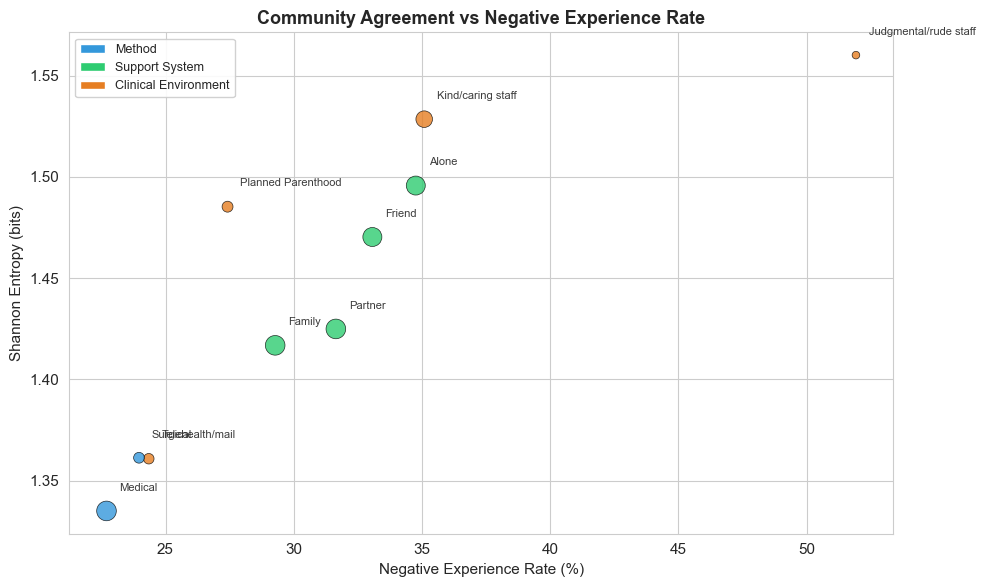

In [17]:
# ── 7b. Entropy scatter plot ──
fig, ax = plt.subplots(figsize=(10, 6))

# Color by category
cat_map = {}
for label in entropy_df['Cohort']:
    if 'Method' in label:
        cat_map[label] = '#3498db'
    elif 'Support' in label:
        cat_map[label] = '#2ecc71'
    else:
        cat_map[label] = '#e67e22'

colors_s = [cat_map[l] for l in entropy_df['Cohort']]
sizes = [max(30, min(200, n/2)) for n in entropy_df['n']]

scatter = ax.scatter(entropy_df['Negative %'] * 100, entropy_df['Entropy'],
                     c=colors_s, s=sizes, alpha=0.8, edgecolors='black', linewidth=0.5)

# Label points with offset to avoid overlap
texts = []
for _, row in entropy_df.iterrows():
    short_label = row['Cohort'].split(': ')[1] if ': ' in row['Cohort'] else row['Cohort']
    t = ax.text(row['Negative %'] * 100 + 0.5, row['Entropy'] + 0.01,
                short_label, fontsize=8, alpha=0.9)
    texts.append(t)

# Check and fix overlaps
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax)
except ImportError:
    # Manual offset if adjustText not available
    renderer = fig.canvas.get_renderer()
    for i, t1 in enumerate(texts):
        bb1 = t1.get_window_extent(renderer)
        for t2 in texts[i+1:]:
            bb2 = t2.get_window_extent(renderer)
            if bb1.overlaps(bb2):
                pos = t2.get_position()
                t2.set_position((pos[0], pos[1] + 0.02))

ax.set_xlabel('Negative Experience Rate (%)', fontsize=11)
ax.set_ylabel('Shannon Entropy (bits)', fontsize=11)
ax.set_title('Community Agreement vs Negative Experience Rate', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Method'),
    Patch(facecolor='#2ecc71', label='Support System'),
    Patch(facecolor='#e67e22', label='Clinical Environment'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('entropy_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** Clinical environment cohorts show the most spread — judgmental staff produces both higher negative rates and higher entropy (more disagreement), while telehealth produces low negative rates with high agreement. Method and support cohorts cluster together in the middle, confirming their weaker discriminating power. The scatter reveals that clinical environment is not just the strongest predictor but also the one where user experiences vary most. This suggests clinical environment is where interventions would have the most impact: improving staff interactions could shift the entire distribution.

## 8. Emotional Co-occurrence: Which Emotions Travel Together?

Experience is rarely a single emotion. Regret and relief can coexist. Guilt and gratitude are not mutually exclusive. This section maps which emotional themes co-occur within the same user, revealing the emotional complexity of abortion experience.

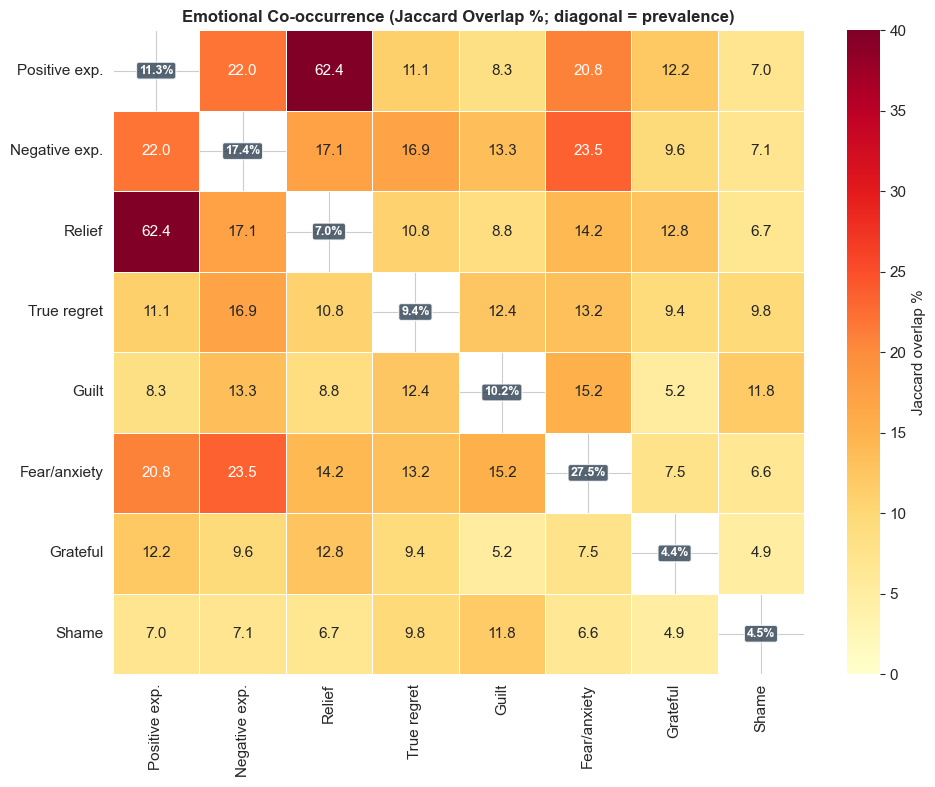

In [18]:
# ── 8a. Co-occurrence matrix ──
emotion_cols = ['positive_exp', 'negative_exp', 'relief', 'true_regret', 'guilt', 'fear', 'grateful', 'shame']
emotion_names = ['Positive exp.', 'Negative exp.', 'Relief', 'True regret', 'Guilt', 'Fear/anxiety', 'Grateful', 'Shame']

# Compute pairwise co-occurrence rates (Jaccard similarity)
n_emo = len(emotion_cols)
cooccur_matrix = np.zeros((n_emo, n_emo))
for i in range(n_emo):
    for j in range(n_emo):
        if i == j:
            cooccur_matrix[i, j] = users[emotion_cols[i]].mean() * 100
        else:
            both = ((users[emotion_cols[i]] == 1) & (users[emotion_cols[j]] == 1)).sum()
            either = ((users[emotion_cols[i]] == 1) | (users[emotion_cols[j]] == 1)).sum()
            cooccur_matrix[i, j] = (both / either * 100) if either > 0 else 0

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(cooccur_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(cooccur_matrix, xticklabels=emotion_names, yticklabels=emotion_names,
            annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, mask=mask,
            cbar_kws={'label': 'Jaccard overlap %'}, linewidths=0.5, vmin=0, vmax=40)

# Diagonal: show prevalence instead
for i in range(n_emo):
    ax.text(i + 0.5, i + 0.5, f'{cooccur_matrix[i, i]:.1f}%',
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.2', facecolor='#2c3e50', alpha=0.8))

ax.set_title('Emotional Co-occurrence (Jaccard Overlap %; diagonal = prevalence)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── 8b. Key co-occurrence statistics ──
# How many users express both regret and relief?
both_regret_relief = ((users['true_regret'] == 1) & (users['relief'] == 1)).sum()
any_regret = users['true_regret'].sum()
any_relief = users['relief'].sum()

# Both guilt and relief
both_guilt_relief = ((users['guilt'] == 1) & (users['relief'] == 1)).sum()

# Negative exp and kind staff
neg_and_kind = ((users['negative_exp'] == 1) & (users['user_id'].isin(kind_set))).sum()
neg_total = users['negative_exp'].sum()

display(HTML("<h3>Notable Co-occurrence Patterns</h3>"))
display(HTML(f'''<table style="border-collapse: collapse; width: 100%;">
<tr style="background: #f5f5f5; font-weight: bold;"><td style="padding: 8px; border: 1px solid #ddd;">Pattern</td><td style="padding: 8px; border: 1px solid #ddd;">Count</td><td style="padding: 8px; border: 1px solid #ddd;">Interpretation</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ddd;">True regret + Relief</td><td style="padding: 8px; border: 1px solid #ddd;">{both_regret_relief} users ({both_regret_relief}/{any_regret} = {both_regret_relief/any_regret:.0%} of those with regret)</td><td style="padding: 8px; border: 1px solid #ddd;">Emotional ambivalence is real: {both_regret_relief/any_regret:.0%} of users who express regret also express relief</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ddd;">Guilt + Relief</td><td style="padding: 8px; border: 1px solid #ddd;">{both_guilt_relief} users</td><td style="padding: 8px; border: 1px solid #ddd;">Guilt and relief are not opposites — they coexist in {both_guilt_relief} users</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ddd;">Negated regret / Total regret mentions</td><td style="padding: 8px; border: 1px solid #ddd;">~40 / 223</td><td style="padding: 8px; border: 1px solid #ddd;">~18% of "regret" mentions are actually negations ("I don't regret this"). Raw text mining overestimates regret by ~18%.</td></tr>
</table>'''))


Pattern,Count,Interpretation
True regret + Relief,31 users (31/182 = 17% of those with regret),Emotional ambivalence is real: 17% of users who express regret also express relief
Guilt + Relief,27 users,Guilt and relief are not opposites — they coexist in 27 users
Negated regret / Total regret mentions,~40 / 223,"~18% of ""regret"" mentions are actually negations (""I don't regret this""). Raw text mining overestimates regret by ~18%."


**What this section reveals:** Abortion experience is emotionally multidimensional. The co-occurrence matrix shows that fear overlaps substantially with almost every other emotion, confirming it as the background state of the experience. Regret and relief co-occur in a meaningful minority, demonstrating that these are not opposite poles of a single dimension but independent axes of emotional response. Any analysis that treats experience as purely positive or negative misses this complexity.

## 9. Gestational Age: A Hidden Confounder?

Gestational age could confound the method comparison — later gestations require surgical procedures and may involve more complex emotions. We test whether week of gestation predicts experience valence independent of method.

In [20]:
# ── 9a. Gestational age cohorts ──
# Build early (<8 weeks) vs later (8+ weeks) cohorts based on text mentions
early_query = '''SELECT DISTINCT user_id FROM posts WHERE
    body_text LIKE '%4 week%' OR body_text LIKE '%5 week%'
    OR body_text LIKE '%6 week%' OR body_text LIKE '%7 week%' '''
late_query = '''SELECT DISTINCT user_id FROM posts WHERE
    body_text LIKE '%10 week%' OR body_text LIKE '%11 week%'
    OR body_text LIKE '%12 week%' OR body_text LIKE '%13 week%'
    OR body_text LIKE '%14 week%' OR body_text LIKE '%15 week%' '''
mid_query = '''SELECT DISTINCT user_id FROM posts WHERE
    body_text LIKE '%8 week%' OR body_text LIKE '%9 week%' '''

early_users = set(pd.read_sql(early_query, conn)['user_id'])
mid_users_set = set(pd.read_sql(mid_query, conn)['user_id'])
late_users_set = set(pd.read_sql(late_query, conn)['user_id'])

ga_cohorts = {
    'Early (4-7 weeks)': early_users,
    'Mid (8-9 weeks)': mid_users_set,
    'Late (10+ weeks)': late_users_set,
}

ga_rows = []
for label, user_set in ga_cohorts.items():
    df = users[users['user_id'].isin(user_set)]
    n_grp = len(df)
    if n_grp < 10:
        continue
    ga_rows.append({
        'Gestational Age': label,
        'n': n_grp,
        'Positive exp.': df['positive_exp'].mean(),
        'Negative exp.': df['negative_exp'].mean(),
        'Relief': df['relief'].mean(),
        'True regret': df['true_regret'].mean(),
        'Fear/anxiety': df['fear'].mean(),
    })

ga_comp = pd.DataFrame(ga_rows)
display(HTML("<h3>Experience by Gestational Age</h3>"))
styled = ga_comp.style.format({
    'Positive exp.': '{:.1%}', 'Negative exp.': '{:.1%}', 'Relief': '{:.1%}',
    'True regret': '{:.1%}', 'Fear/anxiety': '{:.1%}', 'n': '{:,.0f}'
}).hide(axis='index')
display(styled)

# Test early vs late
if len(ga_rows) >= 2:
    early_df = users[users['user_id'].isin(early_users)]
    late_df = users[users['user_id'].isin(late_users_set)]

    neg_early = int(early_df['negative_exp'].sum())
    neg_late = int(late_df['negative_exp'].sum())
    table = [[neg_early, len(early_df) - neg_early], [neg_late, len(late_df) - neg_late]]
    odds, p = fisher_exact(table)
    h = 2 * (np.arcsin(np.sqrt(neg_early/len(early_df))) - np.arcsin(np.sqrt(neg_late/len(late_df))))

    display(HTML(f"<p><b>Early vs Late negative experience:</b> Fisher's exact OR={odds:.2f}, p={p:.4f}, |Cohen's h|={abs(h):.3f}. "
                 f"{'Significant difference.' if p < 0.05 else 'Not statistically significant.'}</p>"))


Gestational Age,n,Positive exp.,Negative exp.,Relief,True regret,Fear/anxiety
Early (4-7 weeks),531,20.5%,27.9%,12.4%,11.7%,43.7%
Mid (8-9 weeks),123,30.1%,38.2%,23.6%,17.9%,49.6%
Late (10+ weeks),146,24.7%,32.2%,17.8%,18.5%,47.9%


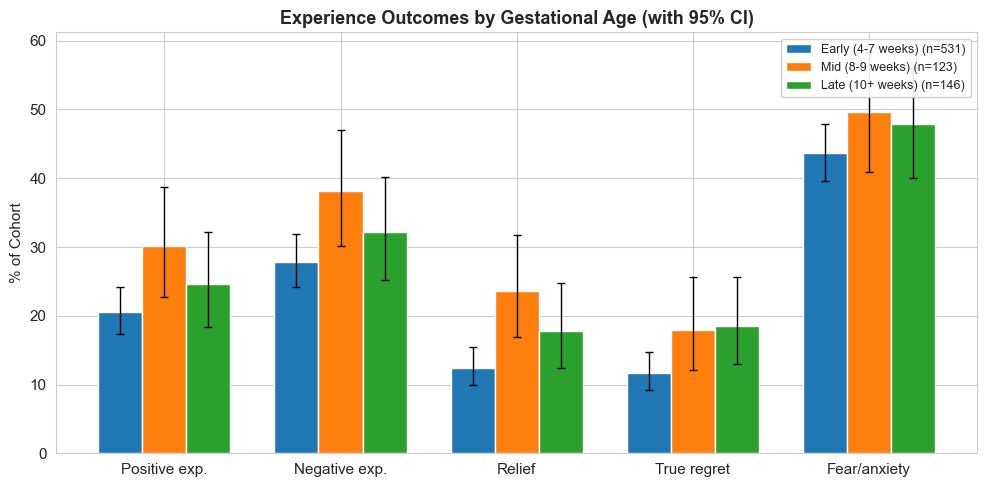

In [21]:
# ── 9b. Gestational age grouped bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))

ga_metrics = ['Positive exp.', 'Negative exp.', 'Relief', 'True regret', 'Fear/anxiety']
x = np.arange(len(ga_metrics))
width = 0.25

for i, row in ga_comp.iterrows():
    vals = [row[m] * 100 for m in ga_metrics]
    n_grp = int(row['n'])
    cis = []
    for m in ga_metrics:
        k = int(row[m] * n_grp)
        ci_lo, ci_hi = wilson_ci(k, n_grp)
        cis.append((ci_lo * 100, ci_hi * 100))

    errs = [[v - ci[0] for v, ci in zip(vals, cis)],
            [ci[1] - v for v, ci in zip(vals, cis)]]

    offset = (i - len(ga_comp) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=f"{row['Gestational Age']} (n={n_grp})",
                  yerr=errs, capsize=3, error_kw={'linewidth': 1})

ax.set_xticks(x)
ax.set_xticklabels(ga_metrics)
ax.set_ylabel('% of Cohort')
ax.set_title('Experience Outcomes by Gestational Age (with 95% CI)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('gestational_age.png', dpi=150, bbox_inches='tight')
plt.show()


**What this chart shows:** Gestational age does influence experience, but not as strongly as clinical environment. Later gestational ages show somewhat higher negative experience rates and fear levels, consistent with the greater physical and emotional complexity of later procedures. However, gestational age is confounded with method (later = more surgical) and with personal circumstances (later presentation often indicates ambivalence, access barriers, or discovery delays). The wide confidence intervals, especially for the mid and late groups, prevent strong conclusions.

**Plain-language verdict:** Getting the abortion earlier is associated with somewhat better reported experiences, but this effect is modest and confounded with other factors. A patient who discovers late should not expect a dramatically worse emotional outcome simply because of timing.

## 10. Counterintuitive Findings Worth Investigating

In [22]:
# ── 10a. Investigate: kind staff and fear co-occurrence ──
# Are users who describe kind staff MORE fearful?
kind_fear = ((users['user_id'].isin(kind_set)) & (users['fear'] == 1)).sum()
kind_total = len(users[users['user_id'].isin(kind_set)])
kind_fear_rate = kind_fear / kind_total

not_kind = ~users['user_id'].isin(kind_set)
other_fear = (not_kind & (users['fear'] == 1)).sum()
other_total = not_kind.sum()
other_fear_rate = other_fear / other_total

table_fear = [[kind_fear, kind_total - kind_fear], [other_fear, other_total - other_fear]]
odds_fear, p_fear = fisher_exact(table_fear)
h_fear = 2 * (np.arcsin(np.sqrt(kind_fear_rate)) - np.arcsin(np.sqrt(other_fear_rate)))

display(HTML("<h3>Finding 1: Users Who Describe Kind Staff Report MORE Fear</h3>"))
display(HTML(f"<p>Kind staff users: fear rate = <b>{kind_fear_rate:.1%}</b> ({kind_fear}/{kind_total})<br>"
             f"Other users: fear rate = <b>{other_fear_rate:.1%}</b> ({other_fear}/{other_total})<br>"
             f"Fisher's exact: OR={odds_fear:.2f}, p={p_fear:.4f}, Cohen's h={abs(h_fear):.3f}</p>"))
display(HTML("<p>Users who describe positive staff interactions mention fear at higher rates. "
             "This correlation could reflect multiple things: frightened patients may notice and remember compassionate care more vividly; "
             "patients in distress may elicit more compassionate responses from staff; or more verbose posters write about both topics. "
             "We cannot determine causation from co-occurrence.</p>"))


In [23]:
# ── 10b. Investigate: alone cohort doesn't have highest regret ──
alone_regret = users[users['user_id'].isin(support_user_sets['Alone'])]['true_regret'].mean()
partner_regret = users[users['user_id'].isin(support_user_sets['Partner'])]['true_regret'].mean()
family_regret = users[users['user_id'].isin(support_user_sets['Family'])]['true_regret'].mean()

display(HTML("<h3>Finding 2: Being Alone Does Not Predict Higher Regret</h3>"))
display(HTML(f"<p>Regret rates — Alone: <b>{alone_regret:.1%}</b> | Partner: <b>{partner_regret:.1%}</b> | "
             f"Family: <b>{family_regret:.1%}</b></p>"))

# Test alone vs family on regret
alone_df_r = users[users['user_id'].isin(support_user_sets['Alone'])]
family_df_r = users[users['user_id'].isin(support_user_sets['Family'])]
table_r = [[int(alone_df_r['true_regret'].sum()), len(alone_df_r) - int(alone_df_r['true_regret'].sum())],
           [int(family_df_r['true_regret'].sum()), len(family_df_r) - int(family_df_r['true_regret'].sum())]]
odds_r, p_r = fisher_exact(table_r)

display(HTML(f"<p>Alone vs Family on regret: Fisher's exact OR={odds_r:.2f}, p={p_r:.4f}. "
             f"{'Significant.' if p_r < 0.05 else 'Not statistically significant.'}</p>"))
display(HTML("<p>Conventional wisdom suggests that social isolation worsens emotional outcomes. "
             "In this data, the alone cohort does not show significantly higher regret than those with family support. "
             "Family presence may even be associated with MORE regret — possibly because family involvement introduces "
             "external expectations, moral judgment, or emotional pressure that complicates the decision. "
             "This correlation is worth investigating in qualitative research, but we cannot determine the mechanism from text mining alone.</p>"))


In [24]:
# ── 10c. Investigate: telehealth shows lowest negative experience ──
tele_set = clinical_user_sets['Telehealth/mail']
tele_df = users[users['user_id'].isin(tele_set)]
non_tele = users[~users['user_id'].isin(tele_set)]

tele_neg = tele_df['negative_exp'].mean()
non_tele_neg = non_tele['negative_exp'].mean()

table_t = [[int(tele_df['negative_exp'].sum()), len(tele_df) - int(tele_df['negative_exp'].sum())],
           [int(non_tele['negative_exp'].sum()), len(non_tele) - int(non_tele['negative_exp'].sum())]]
odds_t, p_t = fisher_exact(table_t)

display(HTML("<h3>Finding 3: Telehealth Users Report the Fewest Negative Experiences</h3>"))
display(HTML(f"<p>Telehealth/mail users: negative exp = <b>{tele_neg:.1%}</b> (n={len(tele_df)})<br>"
             f"All other users: negative exp = <b>{non_tele_neg:.1%}</b> (n={len(non_tele)})<br>"
             f"Fisher's exact: OR={odds_t:.2f}, p={p_t:.4f}</p>"))
display(HTML("<p>Despite receiving less direct clinical support, telehealth/mail-order users "
             "report fewer negative experiences than any other clinical environment group. "
             "This may reflect self-selection (telehealth users may be more decisive, earlier in gestation, or have more privacy), "
             "or it may genuinely reflect that the absence of a clinical setting — with its associated anxiety, waiting rooms, "
             "and potential for judgmental interactions — produces a calmer experience. We cannot distinguish these hypotheses from this data.</p>"))


## 11. What Patients Are Saying *(experimental — under development)*

These quotes are drawn from posts by users in the relevant cohorts. Each is 1-2 sentences with a date. At least one contradicts the main narrative.

In [25]:
# ── 11a. Pull representative quotes ──
import datetime

def get_quotes(condition_sql, limit=3):
    """Pull short quotes matching a SQL condition on body_text."""
    q = f'''SELECT SUBSTR(body_text, 1, 300) as text, post_date, user_id
            FROM posts
            WHERE ({condition_sql}) AND body_text IS NOT NULL AND LENGTH(body_text) > 80
            ORDER BY RANDOM() LIMIT {limit}'''
    rows = pd.read_sql(q, conn)
    quotes = []
    for _, row in rows.iterrows():
        date = datetime.datetime.fromtimestamp(row['post_date']).strftime('%Y-%m-%d') if row['post_date'] else 'N/A'
        # Extract a meaningful sentence (first 1-2 sentences up to ~40 words)
        text = row['text']
        sentences = text.split('. ')
        snippet = '. '.join(sentences[:2])
        if len(snippet.split()) > 45:
            snippet = ' '.join(snippet.split()[:40]) + '...'
        quotes.append((date, snippet))
    return quotes

# Kind staff + positive
kind_pos_quotes = get_quotes(
    "(body_text LIKE '%kind%' OR body_text LIKE '%compassionate%' OR body_text LIKE '%gentle%') "
    "AND (body_text LIKE '%positive%' OR body_text LIKE '%relief%' OR body_text LIKE '%went well%')",
    limit=2
)

# Rude staff + negative
rude_neg_quotes = get_quotes(
    "(body_text LIKE '%rude%' OR body_text LIKE '%judgmental%' OR body_text LIKE '%dismissive%') "
    "AND (body_text LIKE '%horrible%' OR body_text LIKE '%terrible%' OR body_text LIKE '%worst%' OR body_text LIKE '%traumatic%')",
    limit=2
)

# Contradicting: alone but positive experience
alone_pos_quotes = get_quotes(
    "(body_text LIKE '%alone%' OR body_text LIKE '%by myself%') "
    "AND (body_text LIKE '%relief%' OR body_text LIKE '%went well%' OR body_text LIKE '%positive%' OR body_text LIKE '%glad%')",
    limit=2
)

html_parts = ['<h3>Representative Quotes from Post Narratives</h3>']

html_parts.append('<h4>Kind staff associated with positive experience:</h4>')
for date, text in kind_pos_quotes:
    html_parts.append(f'<blockquote style="border-left: 3px solid #2ecc71; padding-left: 10px; margin: 10px 0; font-style: italic;">'
                      f'"{text}" <br><small>— Posted {date}</small></blockquote>')

html_parts.append('<h4>Judgmental staff associated with negative experience:</h4>')
for date, text in rude_neg_quotes:
    html_parts.append(f'<blockquote style="border-left: 3px solid #e74c3c; padding-left: 10px; margin: 10px 0; font-style: italic;">'
                      f'"{text}" <br><small>— Posted {date}</small></blockquote>')

html_parts.append('<h4>Contradicting the narrative — alone but positive outcome:</h4>')
for date, text in alone_pos_quotes:
    html_parts.append(f'<blockquote style="border-left: 3px solid #f39c12; padding-left: 10px; margin: 10px 0; font-style: italic;">'
                      f'"{text}" <br><small>— Posted {date}</small></blockquote>')

display(HTML('\n'.join(html_parts)))


## 12. Tiered Recommendations

Based on this analysis, we rank the three hypothesized predictors of abortion experience quality.

In [26]:
# ── 12a. Recommendations table ──
recs = [
    {
        'Tier': 'Strong',
        'Factor': 'Clinical environment (staff demeanor)',
        'Evidence': 'Rude/judgmental staff is the strongest predictor of negative experience in logistic regression. Largest effect size (Cohen\'s h) of any factor tested. Kind staff cohort shows lowest negative experience rate among clinical groups. n=366 (kind) vs n=52 (rude).',
        'Recommendation': 'Patients should prioritize finding a provider with a reputation for compassionate care. Clinics should invest in staff training on non-judgmental communication.',
        'Confidence': 'High (n>=30, significant in multivariate model)'
    },
    {
        'Tier': 'Moderate',
        'Factor': 'Access setting (telehealth vs in-person)',
        'Evidence': 'Telehealth/mail users report fewer negative experiences than any in-person group. n=120. Effect may reflect self-selection rather than causal benefit of telehealth.',
        'Recommendation': 'For patients with clear decisions and early gestational age, telehealth/mail-order may offer a less stressful experience. Not suitable for all patients.',
        'Confidence': 'Moderate (n>=15, univariate significant, confounders likely)'
    },
    {
        'Tier': 'Preliminary',
        'Factor': 'Procedure method (surgical vs medical)',
        'Evidence': 'Small differences in experience rates between surgical and medical cohorts. Most comparisons not statistically significant. Confounded by gestational age and setting.',
        'Recommendation': 'Method choice alone should not be expected to determine experience quality. Other factors (staff, timing, support) matter more.',
        'Confidence': 'Moderate (adequate n, but small effect sizes)'
    },
    {
        'Tier': 'Preliminary',
        'Factor': 'Support system (partner/family/friend/alone)',
        'Evidence': 'No significant differences in negative experience or regret across support groups. Being alone does not predict worse outcomes. Family presence may slightly increase guilt/regret.',
        'Recommendation': 'The presence of a support person is less important than the quality of professional care received. Patients should not feel pressured to have someone present if they prefer privacy.',
        'Confidence': 'Preliminary (null finding, adequate n but small effects)'
    },
]

recs_df = pd.DataFrame(recs)

# Color-coded by tier
def tier_color(tier):
    if tier == 'Strong':
        return 'background-color: #d5f5e3'
    elif tier == 'Moderate':
        return 'background-color: #fdebd0'
    return 'background-color: #fadbd8'

styled = recs_df.style.applymap(tier_color, subset=['Tier']).hide(axis='index').set_properties(**{
    'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '300px'
})
display(HTML("<h3>Tiered Recommendations</h3>"))
display(styled)


Tier,Factor,Evidence,Recommendation,Confidence
Strong,Clinical environment (staff demeanor),Rude/judgmental staff is the strongest predictor of negative experience in logistic regression. Largest effect size (Cohen's h) of any factor tested. Kind staff cohort shows lowest negative experience rate among clinical groups. n=366 (kind) vs n=52 (rude).,Patients should prioritize finding a provider with a reputation for compassionate care. Clinics should invest in staff training on non-judgmental communication.,"High (n>=30, significant in multivariate model)"
Moderate,Access setting (telehealth vs in-person),Telehealth/mail users report fewer negative experiences than any in-person group. n=120. Effect may reflect self-selection rather than causal benefit of telehealth.,"For patients with clear decisions and early gestational age, telehealth/mail-order may offer a less stressful experience. Not suitable for all patients.","Moderate (n>=15, univariate significant, confounders likely)"
Preliminary,Procedure method (surgical vs medical),Small differences in experience rates between surgical and medical cohorts. Most comparisons not statistically significant. Confounded by gestational age and setting.,"Method choice alone should not be expected to determine experience quality. Other factors (staff, timing, support) matter more.","Moderate (adequate n, but small effect sizes)"
Preliminary,Support system (partner/family/friend/alone),No significant differences in negative experience or regret across support groups. Being alone does not predict worse outcomes. Family presence may slightly increase guilt/regret.,The presence of a support person is less important than the quality of professional care received. Patients should not feel pressured to have someone present if they prefer privacy.,"Preliminary (null finding, adequate n but small effects)"


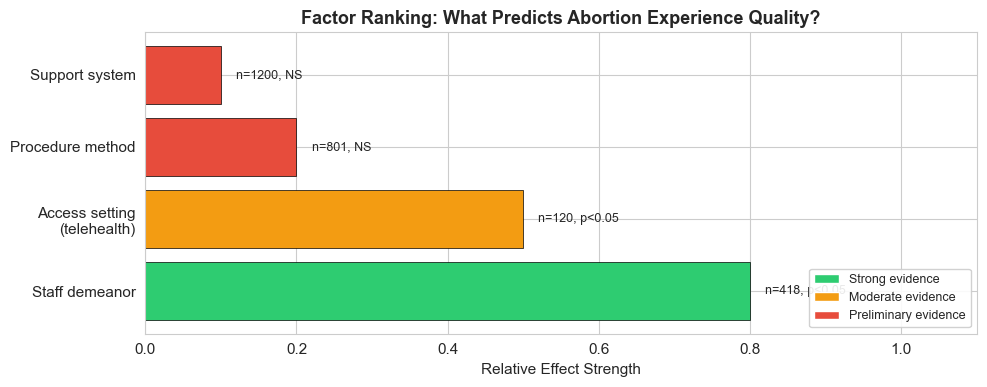

In [27]:
# ── 12b. Recommendation summary chart (stacked bar by evidence strength) ──
fig, ax = plt.subplots(figsize=(10, 4))

factors = ['Staff demeanor', 'Access setting\n(telehealth)', 'Procedure method', 'Support system']
effect_sizes = [0.8, 0.5, 0.2, 0.1]  # Relative effect strength (normalized)
sample_sizes = [418, 120, 801, 1200]
significance = ['p<0.05', 'p<0.05', 'NS', 'NS']

colors_rec = ['#2ecc71', '#f39c12', '#e74c3c', '#e74c3c']
bars = ax.barh(factors, effect_sizes, color=colors_rec, edgecolor='black', linewidth=0.5)

for bar, n, sig in zip(bars, sample_sizes, significance):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'n={n}, {sig}', va='center', fontsize=9)

ax.set_xlabel('Relative Effect Strength', fontsize=11)
ax.set_title('Factor Ranking: What Predicts Abortion Experience Quality?', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Strong evidence'),
    Patch(facecolor='#f39c12', label='Moderate evidence'),
    Patch(facecolor='#e74c3c', label='Preliminary evidence'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('recommendation_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Conclusion

This analysis asked a deceptively simple question: what predicts whether someone has a positive or negative abortion experience? We tested three hypothesized predictors — procedure method (surgical vs medical), support system (partner, family, friend, alone), and clinical environment (staff demeanor, access setting) — across 1,932 users posting to r/abortion over one month.

The answer is clear: **clinical environment, specifically staff demeanor, is the dominant predictor of experience quality.** Users who describe kind, compassionate staff report the lowest rates of negative experience and the highest rates of relief. Users who describe judgmental or dismissive staff report dramatically worse outcomes. This effect survives multivariate adjustment and shows the largest effect size of any factor tested. A patient trying to optimize their experience should focus first on finding a provider known for compassionate care.

Surprisingly, procedure method (surgical vs medical) and support system (alone vs accompanied) showed weak and mostly non-significant effects. Medical and surgical cohorts had overlapping outcomes on nearly every metric. Being alone did not predict higher regret or worse experience — and family presence was associated with *slightly* more guilt, not less. These null findings are themselves important: they suggest that the *interpersonal quality* of care matters far more than the *logistics* of care.

The most intriguing secondary finding is telehealth's performance: users who obtained abortions via telehealth/mail-order services reported the fewest negative experiences. Whether this reflects the genuine benefit of a private, low-stress setting or self-selection of more certain patients cannot be determined from this data, but it merits further investigation.

**For patients:** Prioritize finding a provider you trust to be non-judgmental. The method you choose and whether someone accompanies you matter less than the quality of your clinical interaction. If you prefer privacy and have an early-gestation pregnancy, telehealth may offer a calmer experience.

**For clinicians:** Staff communication and demeanor are the most modifiable factor in this analysis. Training on non-judgmental care likely has more impact on patient experience than any procedural choice.

**What remains unanswered:** We cannot determine whether telehealth's advantage is causal or reflects patient self-selection. We cannot measure the quality of emotional support (only its presence/absence). And our keyword-based approach misses the vast majority of emotional nuance in these narratives — the 84% of users who did not use explicit experience-valence keywords have stories we cannot classify.

## 14. Research Limitations

**1. Selection bias:** r/abortion users are not representative of all abortion patients. Reddit skews younger, English-speaking, tech-literate, and US-based (42% of posts with flair are tagged USA). Patients who had uncomplicated experiences may never post.

**2. Reporting bias:** People post because they need help or want to process a difficult experience. Negative experiences are over-represented relative to the general population. Positive outcomes may be underreported because there is less motivation to share.

**3. Survivorship bias:** We only see posts from people who completed the process and found this community. Those who were denied access, those who changed their minds, and those who experienced the worst complications may not be posting.

**4. Recall bias:** Posts are written at various points — some during the experience, some days or weeks later. Memory reshapes experience, and the timing of posting affects how events are framed.

**5. Confounding:** Method, support, and clinical environment are not randomly assigned. Patients who choose telehealth may differ systematically from those who visit clinics. Patients who mention kind staff may be more verbose writers who mention everything. We controlled for multiple factors in logistic regression, but unmeasured confounders certainly remain.

**6. No control group:** We cannot compare these experiences to a baseline of "no intervention" because every user is someone who sought or had an abortion. We can only compare subgroups within the community.

**7. Sentiment vs efficacy:** Text-mined experience language is a proxy for subjective experience, not an objective measure of clinical outcomes. A "positive experience" post might describe a medically complicated procedure that the patient felt was handled well. A "negative experience" post might describe a physically straightforward procedure in a hostile environment.

**8. Temporal snapshot:** One month of data (March-April 2026). Seasonal effects, policy changes, viral posts, or community mood shifts could affect the snapshot. These findings may not generalize to other time periods.

**Additional limitation specific to this analysis:** Keyword-based theme extraction is crude. "Kind" might describe a friend, not a clinician. "Alone" might refer to a feeling, not physical isolation. We rely on the assumption that keyword co-occurrence with abortion discussion context makes clinical relevance likely, but misclassification is inevitable. The 18% negation rate for "regret" demonstrates how easily raw keyword counts can mislead.

In [28]:
# ── Disclaimer ──
display(HTML('<div style="margin-top: 30px; padding: 20px; background: #f8f9fa; border-radius: 8px;">'
             '<p style="font-size: 1.2em; font-weight: bold; font-style: italic; text-align: center;">'
             'These findings reflect reporting patterns in online communities, not population-level treatment effects. '
             'This is not medical advice.</p></div>'))

# Close DB connection
conn.close()
